# 04_AB_Test_Analysis

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, ttest_ind

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Финальный проект/final_results_to_analyze.csv')
df.head()

,date,client_id,clicks,finish_watch,start_watch,views,watch_time,adds_to_fav,ab_group
0,2025-04-01,1203,1,0,0,0,0.0,0,control
1,2025-04-01,1223,0,0,0,1,0.0,0,test
2,2025-04-01,1323,0,0,0,1,0.0,0,test
3,2025-04-01,1636,0,1,0,0,19.0,0,test
4,2025-04-02,1069,1,0,0,0,0.0,0,control


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
print(df.info())
print(df.isna().sum())
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          100 non-null    object 
 1   client_id     100 non-null    int64  
 2   clicks        100 non-null    int64  
 3   finish_watch  100 non-null    int64  
 4   start_watch   100 non-null    int64  
 5   views         100 non-null    int64  
 6   watch_time    100 non-null    float64
 7   adds_to_fav   100 non-null    int64  
 8   ab_group      100 non-null    object 
dtypes: float64(1), int64(6), object(2)
memory usage: 7.2+ KB
None
date            0
client_id       0
clicks          0
finish_watch    0
start_watch     0
views           0
watch_time      0
adds_to_fav     0
ab_group        0
dtype: int64
0


In [7]:
metrics = df.groupby('ab_group').agg(
    views=('views','sum'),
    clicks=('clicks','sum'),
    watch_time=('watch_time','mean'),
    fav=('adds_to_fav','sum'),
    finish=('finish_watch','sum')
)
metrics['CTR']=metrics['clicks']/metrics['views']
metrics['Avg Watch Time']=df.groupby('ab_group')['watch_time'].mean()
metrics['CR_fav']=metrics['fav']/metrics['clicks'].replace(0,np.nan)
metrics['ARPU']=df.groupby('ab_group')['watch_time'].sum()/df.groupby('ab_group')['client_id'].nunique()
metrics

,views,clicks,watch_time,fav,finish,CTR,Avg Watch Time,CR_fav,ARPU
ab_group,,,,,,,,,
control,22,17,4.096154,0,4,0.772727,4.096154,0.0,4.437500
test,26,10,6.687500,0,5,0.384615,6.687500,0.0,6.829787


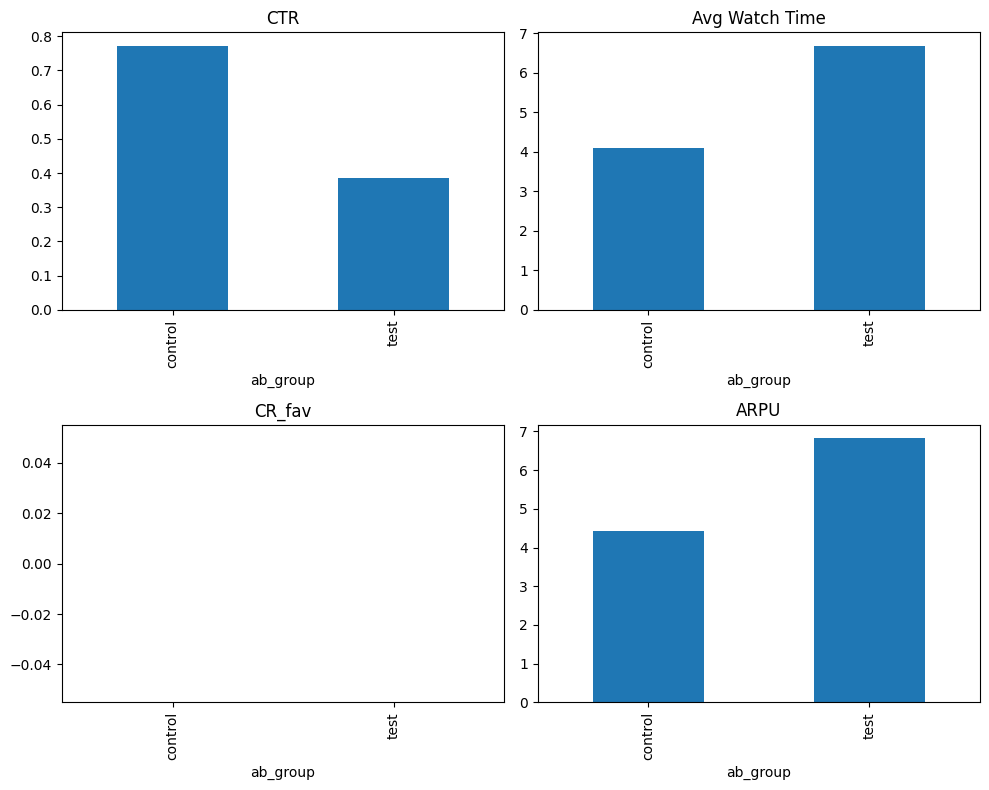

In [8]:
fig,ax=plt.subplots(2,2,figsize=(10,8))
metrics['CTR'].plot(kind='bar',ax=ax[0,0],title='CTR')
metrics['Avg Watch Time'].plot(kind='bar',ax=ax[0,1],title='Avg Watch Time')
metrics['CR_fav'].fillna(0).plot(kind='bar',ax=ax[1,0],title='CR_fav')
metrics['ARPU'].plot(kind='bar',ax=ax[1,1],title='ARPU')
plt.tight_layout()

In [9]:
control=df[df.ab_group=='control']['watch_time']
test=df[df.ab_group=='test']['watch_time']

print('Shapiro control', shapiro(control))
print('Shapiro test', shapiro(test))

print('T-test',ttest_ind(control,test,equal_var=False))

Shapiro control ShapiroResult(statistic=np.float64(0.26929929602823766), pvalue=np.float64(1.2039013633182777e-14))
Shapiro test ShapiroResult(statistic=np.float64(0.32266552955797057), pvalue=np.float64(1.48897739728105e-13))
T-test TtestResult(statistic=np.float64(-0.6287543906711502), pvalue=np.float64(0.5312173517059776), df=np.float64(83.9302802069276))


95% CI: [-4.78846154  2.45673077 10.78529647]


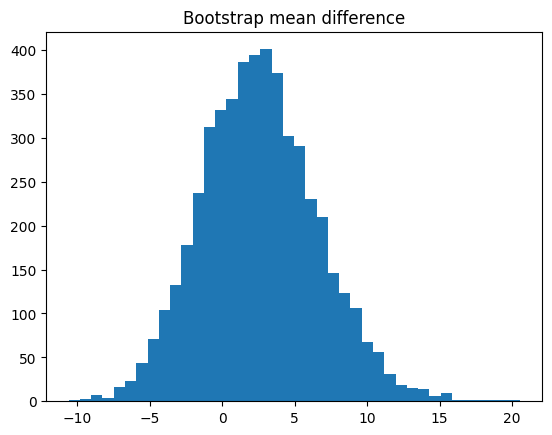

In [10]:
def bootstrap(a,b,n_boot=5000):
    diffs=[]
    a=np.array(a); b=np.array(b)
    for _ in range(n_boot):
        sa=np.random.choice(a,len(a),replace=True)
        sb=np.random.choice(b,len(b),replace=True)
        diffs.append(sb.mean()-sa.mean())
    return np.percentile(diffs,[2.5,50,97.5]),diffs

ci,diffs=bootstrap(control,test)
print('95% CI:',ci)
plt.hist(diffs,bins=40)
plt.title('Bootstrap mean difference')
plt.show()

In [11]:
lift={}
for m in ['CTR','Avg Watch Time','CR_fav','ARPU']:
    c=metrics.loc['control',m]
    t=metrics.loc['test',m]
    lift[m]=(t-c)/c*100 if pd.notna(c) and c!=0 else np.nan
pd.Series(lift,name='Lift_%')

,Lift_%
CTR,-50.226244
Avg Watch Time,63.262911
CR_fav,NaN
ARPU,53.910698


In [12]:
print('Вывод:')
print('- Проверены данные.')
print('- Рассчитаны основные продуктовые метрики.')
print('- Выполнены Shapiro test, t-test и bootstrap.')
print('- Lift рассчитан для всех метрик.')
print('Окончательное решение принимается по статистической значимости и бизнес-эффекту.')

Вывод:
- Проверены данные.
- Рассчитаны основные продуктовые метрики.
- Выполнены Shapiro test, t-test и bootstrap.
- Lift рассчитан для всех метрик.
Окончательное решение принимается по статистической значимости и бизнес-эффекту.
